**1. Dataset Selection**

India Multi-City Air Quality Dataset

The dataset contains air-quality measurements collected from different cities and monitoring locations in India. It includes major pollutants such as PM2.5, PM10, O₃, NO₂, SO₂, and CO, along with the city, location, and date.

**Dataset Source**

Source: https://www.kaggle.com/datasets/riteshswami08/india-multi-city-air-quality-dataset-100k-rows

**Dataset Structure**

The dataset contains 96,755 records and 9 columns:

Column	       Description
City	      Name of the city
Location	  Monitoring location
Date	      Date of measurement
PM2.5	      Fine particulate matter
PM10	      Particulate matter
O₃	          Ozone
NO₂	          Nitrogen dioxide
SO₂	          Sulfur dioxide
CO	          Carbon monoxide

**Why This Dataset Was Selected**

This dataset is suitable because it provides historical pollution data from multiple locations, which can help us understand how pollution changes over time and across cities. It also contains several pollutants that can be used together to predict future PM2.5 levels.

The dataset is also large enough for machine-learning modelling and has relatively few missing values, making it practical for this project.

**2. Problem Statement**

*Problem*

Air pollution levels can change from one day to another depending on the location and the levels of different pollutants. PM2.5 is one of the most important pollutants to monitor, as high concentrations can indicate poor air quality.

In this project, we aim to develop a machine-learning model that uses previous air-quality measurements such as PM2.5, PM10, O₃, NO₂, SO₂, and CO to predict the PM2.5 concentration for the next day.

**Purpose**

The main purpose is to identify patterns in historical pollution data and use them to make an early prediction of future PM2.5 levels.

**Real-World Relevance**

Accurate next-day predictions can help in early pollution monitoring and planning. Authorities can use such predictions to identify locations where pollution may increase and take preventive measures when required.

In [3]:
# ============================================================
# STEP 1: IMPORT LIBRARIES AND LOAD DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Load dataset
df = pd.read_csv("india_air_quality_consolidated.csv")

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

print("\nFirst 5 records:")
print(df.head())


print("Last 5 records:")
print(df.tail())

Dataset loaded successfully!
Shape of dataset: (96755, 9)

First 5 records:
    city     location       date  pm25  pm10    o3  no2  so2   co
0  Delhi  Anand Vihar  2025/12/1   260   362   335   39   51   15
1  Delhi  Anand Vihar  2025/12/2   327   198    11   32   18    5
2  Delhi  Anand Vihar  2025/12/3   236   194     7   26    8   17
3  Delhi  Anand Vihar  2025/12/4   224   225     7   35   11   15
4  Delhi  Anand Vihar  2025/12/5   270                           
Last 5 records:
          city                    location        date pm25 pm10   o3 no2 so2  \
96750  Chennai  Velachery Residential Area   2019/6/21             49   6   1   
96751  Chennai  Velachery Residential Area  2018/12/31             38   4   1   
96752  Chennai  Velachery Residential Area  2018/11/29             12   5   2   
96753  Chennai  Velachery Residential Area  2018/12/14             37   4   3   
96754  Chennai  Velachery Residential Area  2019/12/25                  2   2   

        co  
96750   10  

In [4]:
# ============================================================
# STEP 2: BASIC DATASET INFORMATION
# ============================================================

print(df.info())

print("\nColumn Names:")
print(df.columns.tolist())

print("\nStatistical Summary:")
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96755 entries, 0 to 96754
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   city      96755 non-null  object
 1   location  96755 non-null  object
 2   date      96755 non-null  object
 3   pm25      96755 non-null  object
 4   pm10      96755 non-null  object
 5   o3        96755 non-null  object
 6   no2       96755 non-null  object
 7   so2       90132 non-null  object
 8   co        96755 non-null  object
dtypes: object(9)
memory usage: 6.6+ MB
None

Column Names:
['city', 'location', 'date', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co']

Statistical Summary:
         city    location       date   pm25   pm10     o3    no2    so2     co
count   96755       96755      96755  96755  96755  96755  96755  90132  96755
unique     16          38       4343    625    789    291    135    111    132
top     Delhi  R.K. Puram  2020/10/6                                  1      6
freq 

In [5]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

pollutants = ["pm25", "pm10", "o3", "no2", "so2", "co"]

# Convert pollutants to numeric
for column in pollutants:
    df[column] = pd.to_numeric(df[column], errors="coerce")

print("Missing values before handling:")
print(df[pollutants].isnull().sum())



# Fill missing values using city + location median
for column in pollutants:
    df[column] = df.groupby(["city", "location"])[column].transform(
        lambda x: x.fillna(x.median())
    )

# If any missing values still remain, use overall median
for column in pollutants:
    df[column] = df[column].fillna(df[column].median())

print("\nMissing values after handling:")
print(df[pollutants].isnull().sum())

Missing values before handling:
pm25     3410
pm10    15544
o3       6181
no2      6371
so2     16157
co       7769
dtype: int64

Missing values after handling:
pm25    0
pm10    0
o3      0
no2     0
so2     0
co      0
dtype: int64


In [6]:
# ============================================
# OUTLIER DETECTION USING IQR
# ============================================

for column in pollutants:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print("----------------------------------------")
    print(column.upper())
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of outliers:", len(outliers))

----------------------------------------
PM25
Lower limit: -32.0
Upper limit: 304.0
Number of outliers: 4398
----------------------------------------
PM10
Lower limit: -37.5
Upper limit: 230.5
Number of outliers: 8432
----------------------------------------
O3
Lower limit: -20.0
Upper limit: 60.0
Number of outliers: 5352
----------------------------------------
NO2
Lower limit: -17.0
Upper limit: 47.0
Number of outliers: 4439
----------------------------------------
SO2
Lower limit: -3.0
Upper limit: 13.0
Number of outliers: 6782
----------------------------------------
CO
Lower limit: -7.0
Upper limit: 25.0
Number of outliers: 6256


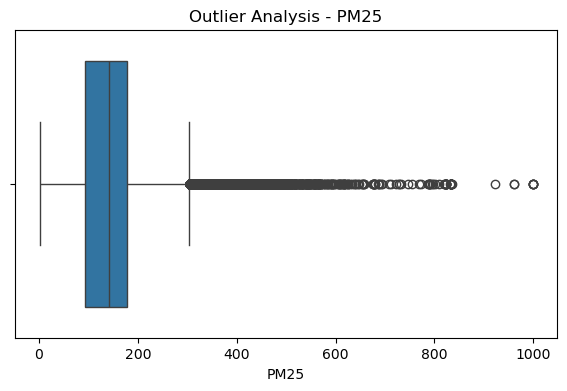

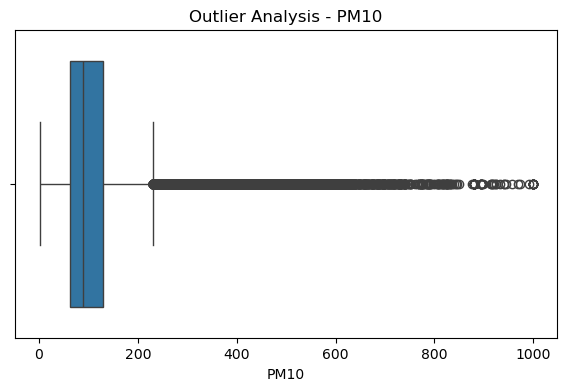

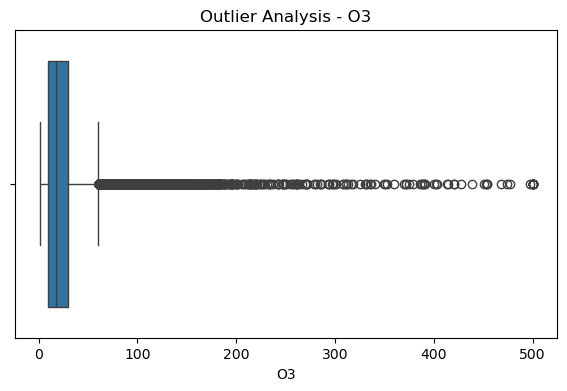

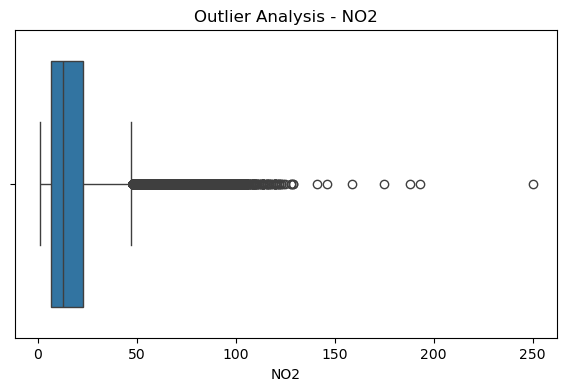

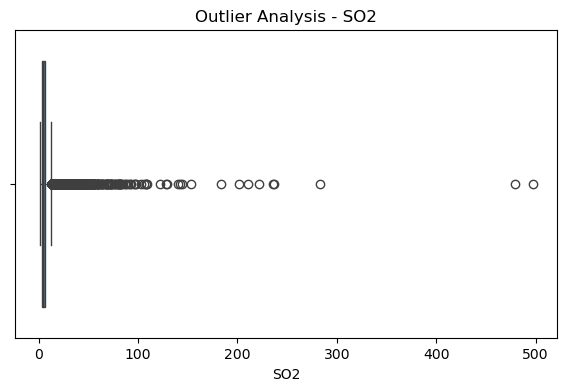

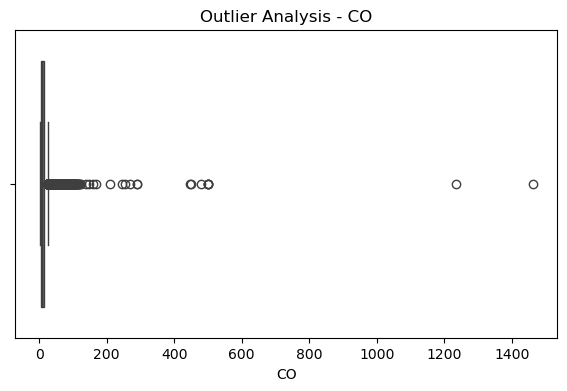

In [7]:
# ============================================
# BOXPLOTS FOR OUTLIER ANALYSIS
# ============================================

for column in pollutants:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[column])
    plt.title("Outlier Analysis - " + column.upper())
    plt.xlabel(column.upper())
    plt.show()

In [91]:
# ============================================
# HANDLE OUTLIERS USING IQR CAPPING
# ============================================

for column in pollutants:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap extreme values
    df[column] = df[column].clip(
        lower=lower_limit,
        upper=upper_limit
    )

print("Outliers handled using IQR capping.")

Outliers handled using IQR capping.


In [20]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Check conversion
print(df["date"].dtype)
print(df["date"].head())

datetime64[ns]
71023   2018-01-20
70957   2018-01-21
70958   2018-01-22
70959   2018-01-23
70960   2018-01-24
Name: date, dtype: datetime64[ns]


In [22]:
# ============================================
# FEATURE ENGINEERING
# ============================================
# Sort data by location and date
df = df.sort_values(["city", "location", "date"])
# Create next-day PM2.5 as target
df["next_day_pm25"] = (
    df.groupby(["city", "location"])["pm25"].shift(-1)
)
# Previous PM2.5 values
df["pm25_lag1"] = (
    df.groupby(["city", "location"])["pm25"].shift(1)
)
df["pm25_lag2"] = (
    df.groupby(["city", "location"])["pm25"].shift(2)
)
df["pm25_lag3"] = (
    df.groupby(["city", "location"])["pm25"].shift(3)
)

# Rolling averages based only on previous days
df["pm25_rolling3"] = (
    df.groupby(["city", "location"])["pm25"]
      .transform(lambda x: x.shift(1).rolling(3).mean())
)
df["pm25_rolling7"] = (
    df.groupby(["city", "location"])["pm25"]
      .transform(lambda x: x.shift(1).rolling(7).mean())
)
# Time-based features
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek

print("Feature engineering completed!")

print("\nNew features:")
print([
    "pm25_lag1",
    "pm25_lag2",
    "pm25_lag3",
    "pm25_rolling3",
    "pm25_rolling7",
    "month",
    "day_of_week",
    "next_day_pm25"
])

print("\nSample of engineered data:")
print(df[
    ["city", "location", "date",
     "pm25", "pm25_lag1", "pm25_lag2",
     "pm25_rolling3", "pm25_rolling7",
     "next_day_pm25"]
].head(15))

# Remove rows where required forecasting features are unavailable
df = df.dropna(
    subset=[
        "next_day_pm25",
        "pm25_lag1",
        "pm25_lag2",
        "pm25_lag3",
        "pm25_rolling3",
        "pm25_rolling7"
    ]
)

print("\nFinal dataset shape after feature engineering:", df.shape)

Feature engineering completed!

New features:
['pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_rolling3', 'pm25_rolling7', 'month', 'day_of_week', 'next_day_pm25']

Sample of engineered data:
        city      location       date   pm25  pm25_lag1  pm25_lag2  \
71023  Alwar  Moti Doongri 2018-01-20  106.0        NaN        NaN   
70957  Alwar  Moti Doongri 2018-01-21  165.0      106.0        NaN   
70958  Alwar  Moti Doongri 2018-01-22  181.0      165.0      106.0   
70959  Alwar  Moti Doongri 2018-01-23  208.0      181.0      165.0   
70960  Alwar  Moti Doongri 2018-01-24  169.0      208.0      181.0   
70961  Alwar  Moti Doongri 2018-01-25  142.0      169.0      208.0   
70962  Alwar  Moti Doongri 2018-01-26  125.0      142.0      169.0   
70963  Alwar  Moti Doongri 2018-01-27  150.0      125.0      142.0   
70964  Alwar  Moti Doongri 2018-01-28   51.0      150.0      125.0   
70965  Alwar  Moti Doongri 2018-01-29   33.0       51.0      150.0   
70966  Alwar  Moti Doongri 2018-01-30   6

In [24]:
print("Invalid dates:", df["date"].isna().sum())

Invalid dates: 0


In [28]:
# ============================================
# STEP 4.1 : PREPARE FEATURES AND TARGET
# ============================================

features = [
    "city",
    "location",
    "pm25",
    "pm10",
    "o3",
    "no2",
    "so2",
    "co",
    "pm25_lag1",
    "pm25_lag2",
    "pm25_lag3",
    "pm25_rolling3",
    "pm25_rolling7",
    "month",
    "day_of_week"
]

target = "next_day_pm25"



In [30]:
X = df[features]
Y = df[target]

print("Input features:", X.shape)
print("Target:", Y.shape)

print("\nFeatures used:")
for feature in features:
    print("-", feature)

print("\nTarget variable:", target)

Input features: (96451, 15)
Target: (96451,)

Features used:
- city
- location
- pm25
- pm10
- o3
- no2
- so2
- co
- pm25_lag1
- pm25_lag2
- pm25_lag3
- pm25_rolling3
- pm25_rolling7
- month
- day_of_week

Target variable: next_day_pm25


In [32]:
# ============================================
# Step 4 : Split the dataset for training and testing
# Chronological Split
# ============================================

print("="*60)
print("Step 4 : Split the dataset for training and testing")
print("="*60)

# Sort data chronologically
df = df.sort_values("date")

# Find the 80% time cutoff
cutoff_date = df["date"].quantile(0.80)

# Split based on time
train_data = df[df["date"] <= cutoff_date]
test_data = df[df["date"] > cutoff_date]

# Create training and testing data
X_train = train_data[features]
X_test = test_data[features]

Y_train = train_data[target]
Y_test = test_data[target]

print("="*60)
print("Information of training and testing data")

print("Cutoff date :", cutoff_date)

print("X_train shape : ", X_train.shape)
print("X_test shape  : ", X_test.shape)
print("Y_train shape : ", Y_train.shape)
print("Y_test shape  : ", Y_test.shape)

print("="*60)

Step 4 : Split the dataset for training and testing
Information of training and testing data
Cutoff date : 2024-04-26 00:00:00
X_train shape :  (77175, 15)
X_test shape  :  (19276, 15)
Y_train shape :  (77175,)
Y_test shape  :  (19276,)


In [34]:
# Categorical features
categorical_features = ["city", "location"]

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessing setup completed!")
print("Categorical features:", categorical_features)
print("Numerical features:", [f for f in features if f not in categorical_features])

Preprocessing setup completed!
Categorical features: ['city', 'location']
Numerical features: ['pm25', 'pm10', 'o3', 'no2', 'so2', 'co', 'pm25_lag1', 'pm25_lag2', 'pm25_lag3', 'pm25_rolling3', 'pm25_rolling7', 'month', 'day_of_week']


In [36]:
# Create baseline pipeline
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train the model
baseline_model.fit(X_train, Y_train)

# Make predictions
baseline_predictions = baseline_model.predict(X_test)
# Evaluate
baseline_mae = mean_absolute_error(Y_test, baseline_predictions)
baseline_rmse = np.sqrt(mean_squared_error(Y_test, baseline_predictions))
baseline_r2 = r2_score(Y_test, baseline_predictions)

print("=" * 60)
print("BASELINE MODEL: LINEAR REGRESSION")
print("=" * 60)

print("MAE  :", round(baseline_mae, 3))
print("RMSE :", round(baseline_rmse, 3))
print("R²   :", round(baseline_r2, 3))

                 city                    location   pm25   pm10    o3   no2  \
91560       Faridabad                  Sector 16A  144.0   89.0   5.0   5.0   
75420          Kanpur       Nehru Nagar Duplicate  107.0   51.0  55.0  13.0   
71562          Kanpur                 Nehru Nagar  107.0   51.0  55.0  13.0   
20045           Delhi         Pooth Khurd, Bawana  136.0  145.0  23.0   4.0   
88265       Faridabad                   Sector 11  202.0  169.0   5.0  11.0   
...               ...                         ...    ...    ...   ...   ...   
94318         Chennai  Velachery Residential Area   77.0   91.0   1.0   5.0   
23960          Mumbai               Borivali East  141.0   74.0  55.0  33.0   
40585       Hyderabad          ICRISAT Patancheru  153.0  108.0  19.0   4.0   
43125       Hyderabad  Zoo Park, Bahadurpura West  136.0   87.0   9.0  10.0   
55688  Chikkamagaluru              Kalyana Nagara   17.0   30.0   3.0   8.0   

        so2    co  pm25_lag1  pm25_lag2  pm25_lag3 

In [42]:
comparison = pd.DataFrame({
    "Actual PM2.5": Y_test.values,
    "Predicted PM2.5": baseline_predictions
})

print(comparison.head(20))



    Actual PM2.5  Predicted PM2.5
0          130.0       138.884252
1          112.0       114.516780
2          112.0       114.516780
3          139.0       146.454356
4          198.0       191.391065
5          160.0       131.610558
6          170.0       143.556407
7          135.0       137.222665
8          117.0       105.326975
9          186.0       198.380650
10         127.0       119.999684
11         130.0       126.824993
12         148.0       166.396392
13         152.0       122.789539
14         104.0       105.226922
15         114.0       123.744391
16         132.0       108.086986
17          65.0        79.745882
18         116.0       108.421731
19         126.0       135.371960


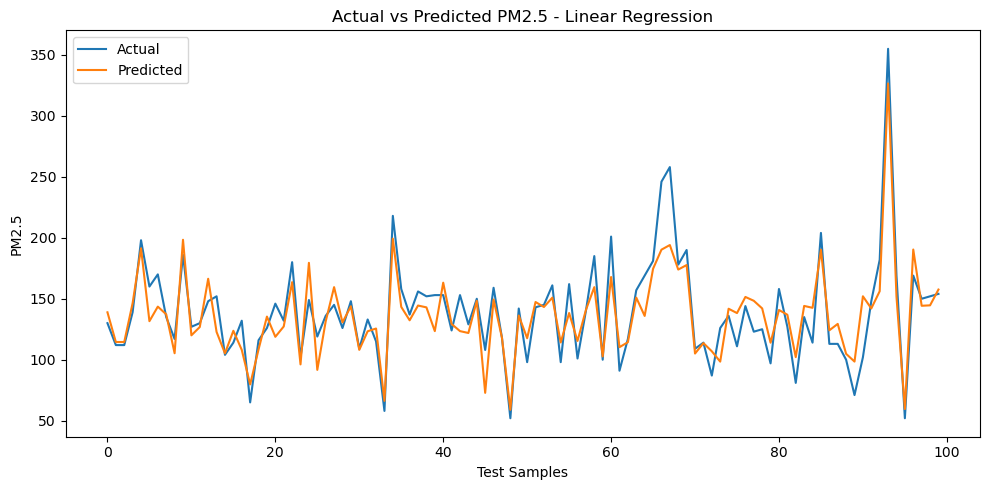

In [44]:
plt.figure(figsize=(10, 5))

plt.plot(Y_test.values[:100], label="Actual")
plt.plot(baseline_predictions[:100], label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("PM2.5")
plt.title("Actual vs Predicted PM2.5 - Linear Regression")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
# ============================================
# STEP 7: CUSTOMIZED MODEL - RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestRegressor

# Create customized Random Forest pipeline
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

print("Training Random Forest...")
 
# Train
rf_model.fit(X_train, Y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

# Evaluate
rf_mae = mean_absolute_error(Y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_predictions))
rf_r2 = r2_score(Y_test, rf_predictions)

print("\n" + "=" * 60)
print("CUSTOMIZED MODEL: RANDOM FOREST")
print("=" * 60)

print("MAE  :", round(rf_mae, 3))
print("RMSE :", round(rf_rmse, 3))
print("R²   :", round(rf_r2, 3))

Training Random Forest...

CUSTOMIZED MODEL: RANDOM FOREST
MAE  : 18.404
RMSE : 35.26
R²   : 0.749


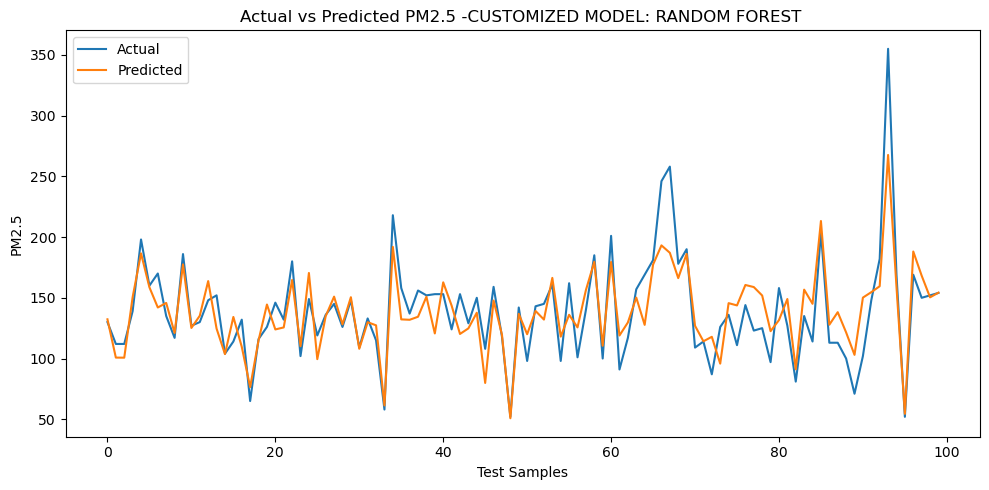

In [50]:
plt.figure(figsize=(10, 5))

plt.plot(Y_test.values[:100], label="Actual")
plt.plot(rf_predictions[:100], label="Predicted")

plt.xlabel("Test Samples")
plt.ylabel("PM2.5")
plt.title("Actual vs Predicted PM2.5 -CUSTOMIZED MODEL: RANDOM FOREST ")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# ============================================
# PERFORMANCE IMPROVEMENT
# ============================================

mae_improvement = (
    (baseline_mae - rf_mae) / baseline_mae
) * 100

rmse_improvement = (
    (baseline_rmse - rf_rmse) / baseline_rmse
) * 100

r2_improvement = (
    (rf_r2 - baseline_r2) / abs(baseline_r2)
) * 100

print("\nPerformance Improvement:")
print("MAE improvement :", round(mae_improvement, 2), "%")
print("RMSE improvement:", round(rmse_improvement, 2), "%")
print("R² improvement  :", round(r2_improvement, 2), "%")


Performance Improvement:
MAE improvement : 8.36 %
RMSE improvement: 1.58 %
R² improvement  : 1.1 %


In [39]:
# Feature Importance from Random Forest

rf_preprocessor = rf_model.named_steps["preprocessor"]
rf_regressor = rf_model.named_steps["model"]

# Get feature names after preprocessing
feature_names = rf_preprocessor.get_feature_names_out()

# Get importance values
importance_values = rf_regressor.feature_importances_

# Create feature importance dataframe
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
}).sort_values("Importance", ascending=False)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
                              Feature  Importance
54                    remainder__pm25    0.711429
55                    remainder__pm10    0.135532
64           remainder__pm25_rolling7    0.026206
59                      remainder__co    0.016302
60               remainder__pm25_lag1    0.014359
57                     remainder__no2    0.011717
63           remainder__pm25_rolling3    0.011470
61               remainder__pm25_lag2    0.010362
62               remainder__pm25_lag3    0.009926
65                   remainder__month    0.009904
56                      remainder__o3    0.008937
58                     remainder__so2    0.007860
66             remainder__day_of_week    0.004805
16  categorical__location_Anand Vihar    0.002865
49    categorical__location_Talkatora    0.001629


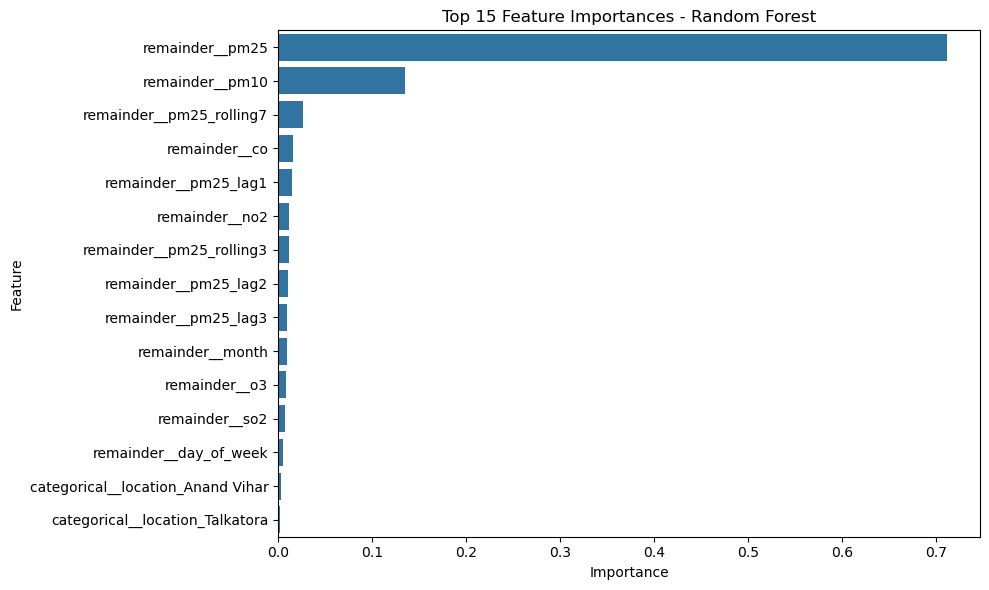

In [41]:
# Visualize Top 15 Feature Importances

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [43]:
# Final Model Comparison

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [baseline_mae, rf_mae],
    "RMSE": [baseline_rmse, rf_rmse],
    "R2 Score": [baseline_r2, rf_r2]
})

print("Model Performance Comparison:")
display(results.round(3))

Model Performance Comparison:


,Model,MAE,RMSE,R2 Score
0,Linear Regression,20.082,35.827,0.741
1,Random Forest,18.404,35.260,0.749


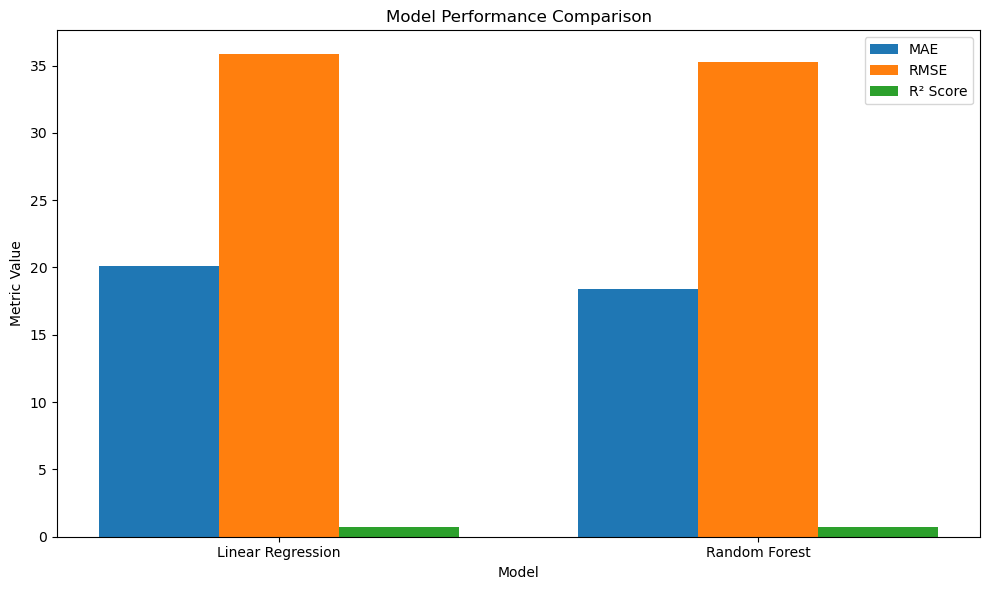

In [47]:
# Grouped Bar Chart - Model Performance Comparison

models = ["Linear Regression", "Random Forest"]

mae_values = [20.082, 18.404]
rmse_values = [35.827, 35.260]
r2_values = [0.741, 0.749]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(10, 6))

plt.bar(x - width, mae_values, width, label="MAE")
plt.bar(x, rmse_values, width, label="RMSE")
plt.bar(x + width, r2_values, width, label="R² Score")

plt.xlabel("Model")
plt.ylabel("Metric Value")
plt.title("Model Performance Comparison")
plt.xticks(x, models)
plt.legend()

plt.tight_layout()
plt.show()

**Justification of Model Improvements**

Random Forest was selected as the customized model because it can capture nonlinear relationships and interactions between pollutant concentrations, historical PM2.5 values, temporal features, and location information, which Linear Regression may not capture effectively. The model uses multiple decision trees and combines their predictions to improve generalization and reduce prediction error.

The improvement is supported by the evaluation results: Random Forest reduced MAE from 20.082 to 18.404 and RMSE from 35.827 to 35.260, while increasing R² from 0.741 to 0.749. Therefore, the customized Random Forest model provides better next-day PM2.5 prediction performance than the baseline Linear Regression model.